# Diagnostic: why don't the Kalman coefficients "converge"?

This notebook reproduces **exactly** the methodology of the reference notebook
([`kalman_sur1h.ipynb`](https://github.com/PierreRobinSchnepf/Applied-Statistics-ENGIE/blob/main/notebooks/archive/kalman_sur1h.ipynb))
on our dataset, to isolate what changes relative to
`models.kalman.HourlyKalmanSURModel` (our "production" version) and to check
whether the observed lack of convergence is a bug or a genuine data effect.

**3 differences between our production model and the reference notebook:**

| | Production (`HourlyKalmanSURModel`) | GitHub reference |
|---|---|---|
| Intercept | **fixed** (SUR's `β_0`, no Kalman factor on it — per the slide) | **dynamic**, slipped into the Kalman state itself (`state[0]`, initialized at 1, NOT anchored on the SUR's `β_0`) |
| Observation noise `V` | estimated automatically per hour (SUR log-space residual variance, ~0.02 at hour 7) | fixed constant **0.1**, tuned for a single equation (hour 7) of another dataset |
| Process noise `W` | uniform scalar **1e-4** over the 25 states | vector **[1e-3, 5e-5, 5e-5, ...]** (intercept component treated separately) |
| Predictors | Table 1 only (26 variables) | Table 1 **+ `trend` + `quad_trend`** (day index, absorbs a long-term drift) |

The 3 settings of the right-hand column are reproduced identically, with and
without `trend`/`quad_trend`, and compared with production — on hour 7, as
the reference notebook does.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, PREDICTOR_COLUMNS
from models.sure import HourlySUREModel
from models.kalman import HourlyKalmanSURModel, _run_kalman, LOG_TARGET_COLUMN, _with_log_target

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
HOUR = 7  # hour studied in the reference notebook

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")

# Context: the target is not stationary over 2018-2025 (structural decline,
# partly tied to the 2022 European energy crisis) — no Table 1 variable
# captures that explicitly.
df["y_gas_mw"].resample("YS").mean().round(0)

build_hourly_equations: panel balanced over 3055 days (days dropped per hour for imbalance: {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})


2018-01-01 00:00:00+00:00    53690.0
2019-01-01 00:00:00+00:00    54672.0
2020-01-01 00:00:00+00:00    50578.0
2021-01-01 00:00:00+00:00    53871.0
2022-01-01 00:00:00+00:00    48395.0
2023-01-01 00:00:00+00:00    42624.0
2024-01-01 00:00:00+00:00    40133.0
2025-01-01 00:00:00+00:00    38899.0
2026-01-01 00:00:00+00:00    44768.0
Freq: YS-JAN, Name: y_gas_mw, dtype: float64

In [2]:
# Add trend/quad_trend (continuous train->test day index), like the reference notebook
all_dates = sorted(set(train[0].index) | set(test[0].index))
trend_map = {d: i + 1 for i, d in enumerate(all_dates)}
for h in range(24):
    train[h] = train[h].copy()
    train[h]["trend"] = train[h].index.map(trend_map).astype(float)
    train[h]["quad_trend"] = train[h]["trend"] ** 2

PRED_NO_TREND = PREDICTOR_COLUMNS
PRED_WITH_TREND = PREDICTOR_COLUMNS + ["trend", "quad_trend"]

log_train = _with_log_target(train, "y_gas_mw")
sure_no_trend = HourlySUREModel(predictor_cols=PRED_NO_TREND).fit(log_train, target_col=LOG_TARGET_COLUMN)
sure_with_trend = HourlySUREModel(predictor_cols=PRED_WITH_TREND).fit(log_train, target_col=LOG_TARGET_COLUMN)

print("SUR coef. (log) trend / quad_trend, hour 7:",
      round(sure_with_trend.coefficients().loc[HOUR, "trend"], 6),
      round(sure_with_trend.coefficients().loc[HOUR, "quad_trend"], 9))

SUR coef. (log) trend / quad_trend, hour 7: 0.0001 -8.8e-08


In [3]:
def build_H_reference_style(sure_model, frame, predictor_cols, hour):
    """H = [1, x_1*beta_SUR_1, ..., x_p*beta_SUR_p] — intercept dynamique
    (colonne de 1, PAS beta_0*1), exactement comme sur_terms_matrix() dans
    the reference notebook."""
    terms = [c for c in predictor_cols if c != "beta_0"]
    beta_sur = sure_model.coefficients().loc[hour, terms].to_numpy(dtype=float)
    X = frame[terms].to_numpy(dtype=float)
    H = np.column_stack([np.ones(len(frame)), X * beta_sur[None, :]])
    return H, ["const_dyn"] + terms

def run_reference_kalman(H, y):
    m = H.shape[1]
    V, W = 0.1, np.concatenate(([1e-3], np.repeat(5e-5, m - 1)))  # EXACT hyperparameters of the reference notebook
    beta_hist, _, _, _ = _run_kalman(H, y, V, W, m)
    return beta_hist

y_train_log = log_train[HOUR][LOG_TARGET_COLUMN].to_numpy()

H_no_trend, names_no_trend = build_H_reference_style(sure_no_trend, log_train[HOUR], PRED_NO_TREND, HOUR)
H_with_trend, names_with_trend = build_H_reference_style(sure_with_trend, log_train[HOUR], PRED_WITH_TREND, HOUR)

traj_faithful_no_trend = pd.DataFrame(run_reference_kalman(H_no_trend, y_train_log), columns=names_no_trend, index=log_train[HOUR].index)
traj_faithful_with_trend = pd.DataFrame(run_reference_kalman(H_with_trend, y_train_log), columns=names_with_trend, index=log_train[HOUR].index)

# Our production model (fixed intercept, in-house V/W), for comparison
prod_model = HourlyKalmanSURModel().fit(train)
traj_production = prod_model.train_beta_history_[HOUR]

## 1. Trajectories of the adjustment factor on `temp_smo` (hour 7, training)

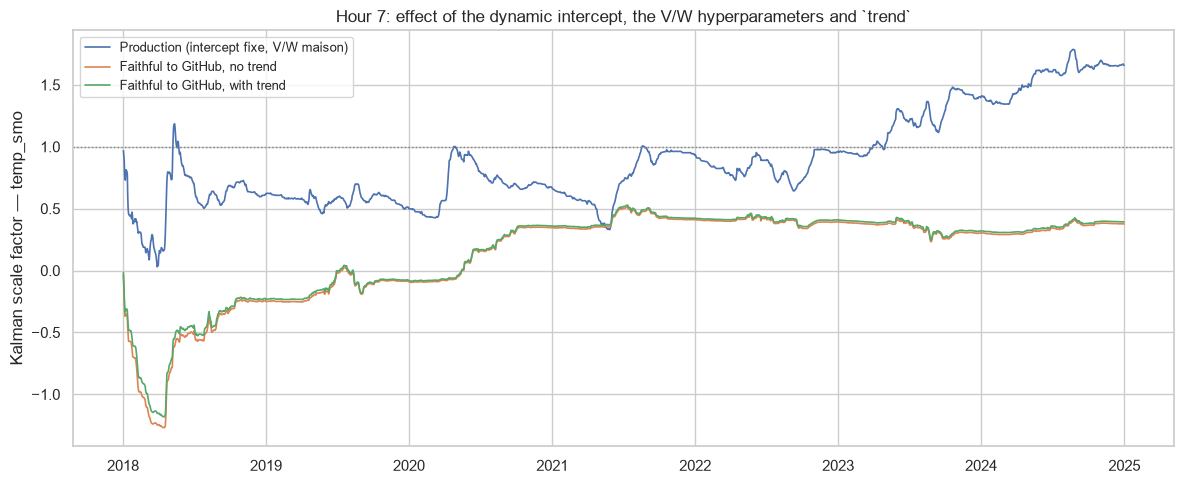

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(traj_production.index, traj_production["temp_smo"], label="Production (intercept fixe, V/W maison)", linewidth=1.2)
ax.plot(traj_faithful_no_trend.index, traj_faithful_no_trend["temp_smo"], label="Faithful to GitHub, no trend", linewidth=1.2)
ax.plot(traj_faithful_with_trend.index, traj_faithful_with_trend["temp_smo"], label="Faithful to GitHub, with trend", linewidth=1.2)
ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_ylabel("Kalman scale factor — temp_smo")
ax.set_title("Hour 7: effect of the dynamic intercept, the V/W hyperparameters and `trend`")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 1bis. Evolution of *all* coefficients (not just `temp_smo`)
One grid per variant, one panel per variable, over the whole training period.

In [5]:
def plot_all_trajectories(traj: pd.DataFrame, title: str, ncols: int = 4):
    cols = list(traj.columns)
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.3 * nrows), squeeze=False)
    axes = axes.ravel()

    for j, col in enumerate(cols):
        ax = axes[j]
        ax.plot(traj.index, traj[col].to_numpy(), lw=1.2, color="#4C72B0")
        ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
        ax.set_title(col, fontsize=9)
        ax.tick_params(axis="x", labelrotation=30, labelsize=7)

    for j in range(len(cols), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

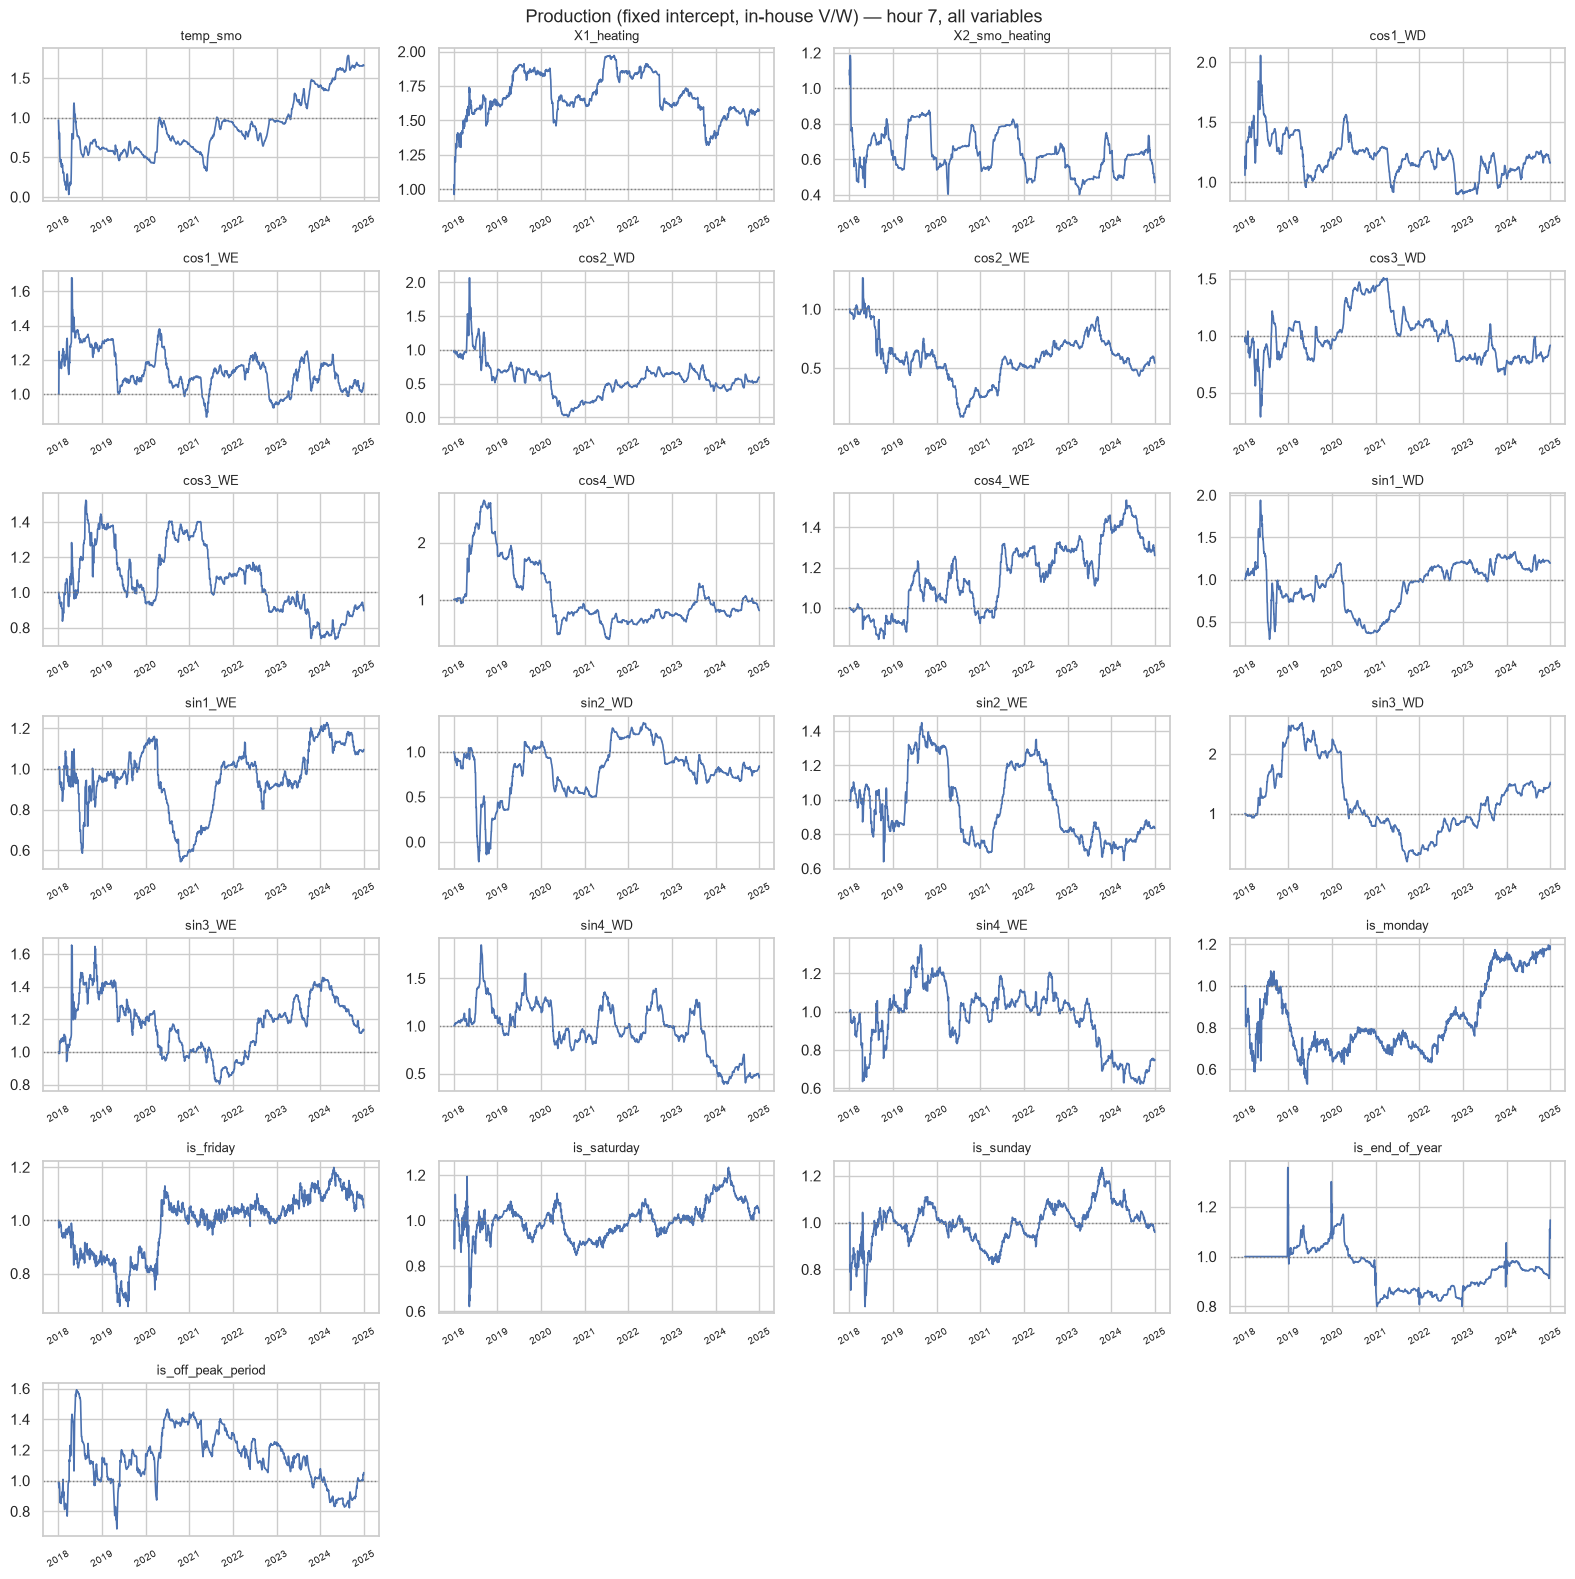

In [6]:
plot_all_trajectories(traj_production, "Production (fixed intercept, in-house V/W) — hour 7, all variables")

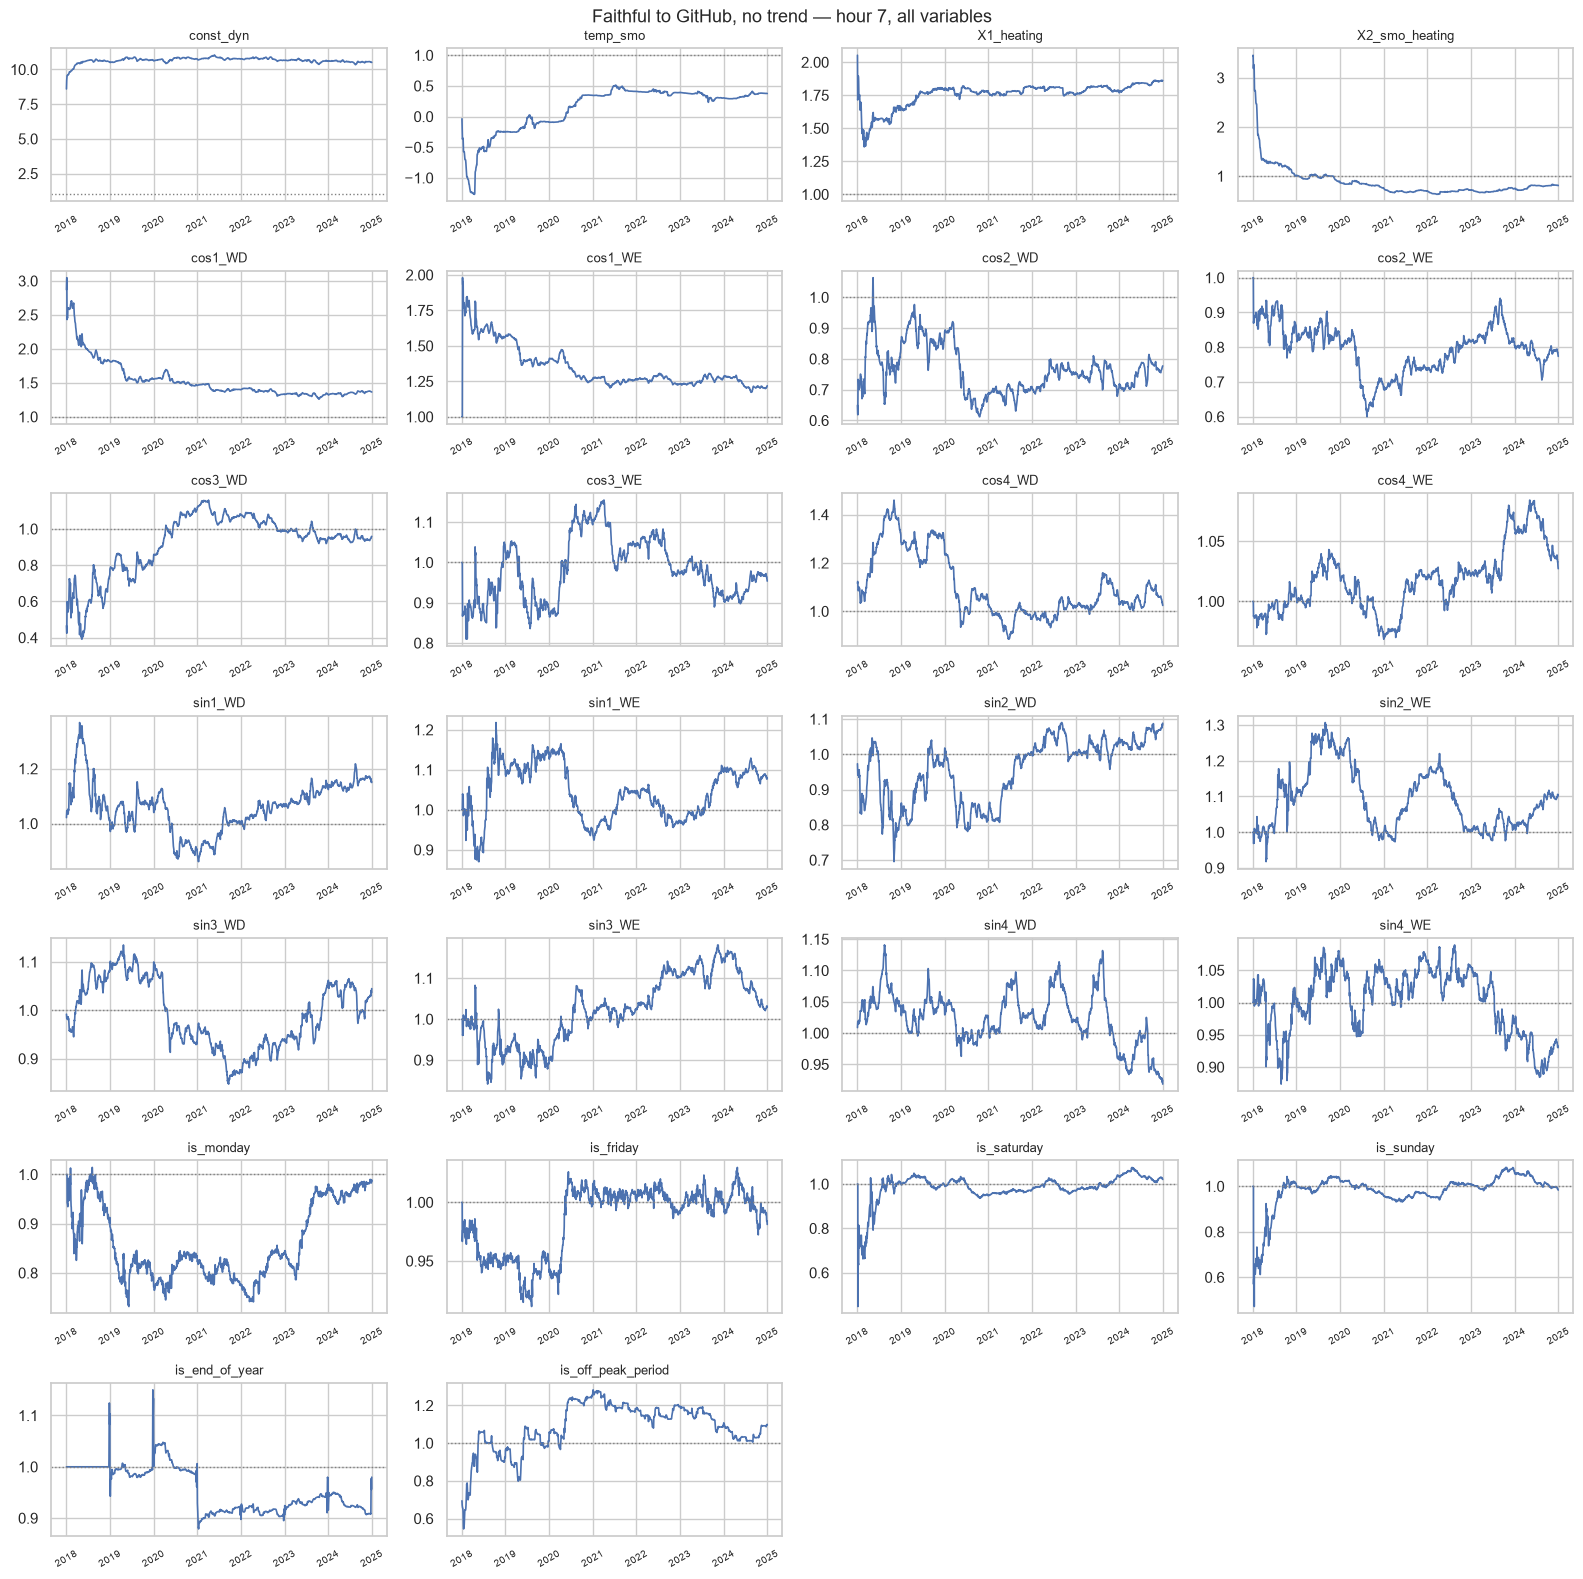

In [7]:
plot_all_trajectories(traj_faithful_no_trend, "Faithful to GitHub, no trend — hour 7, all variables")

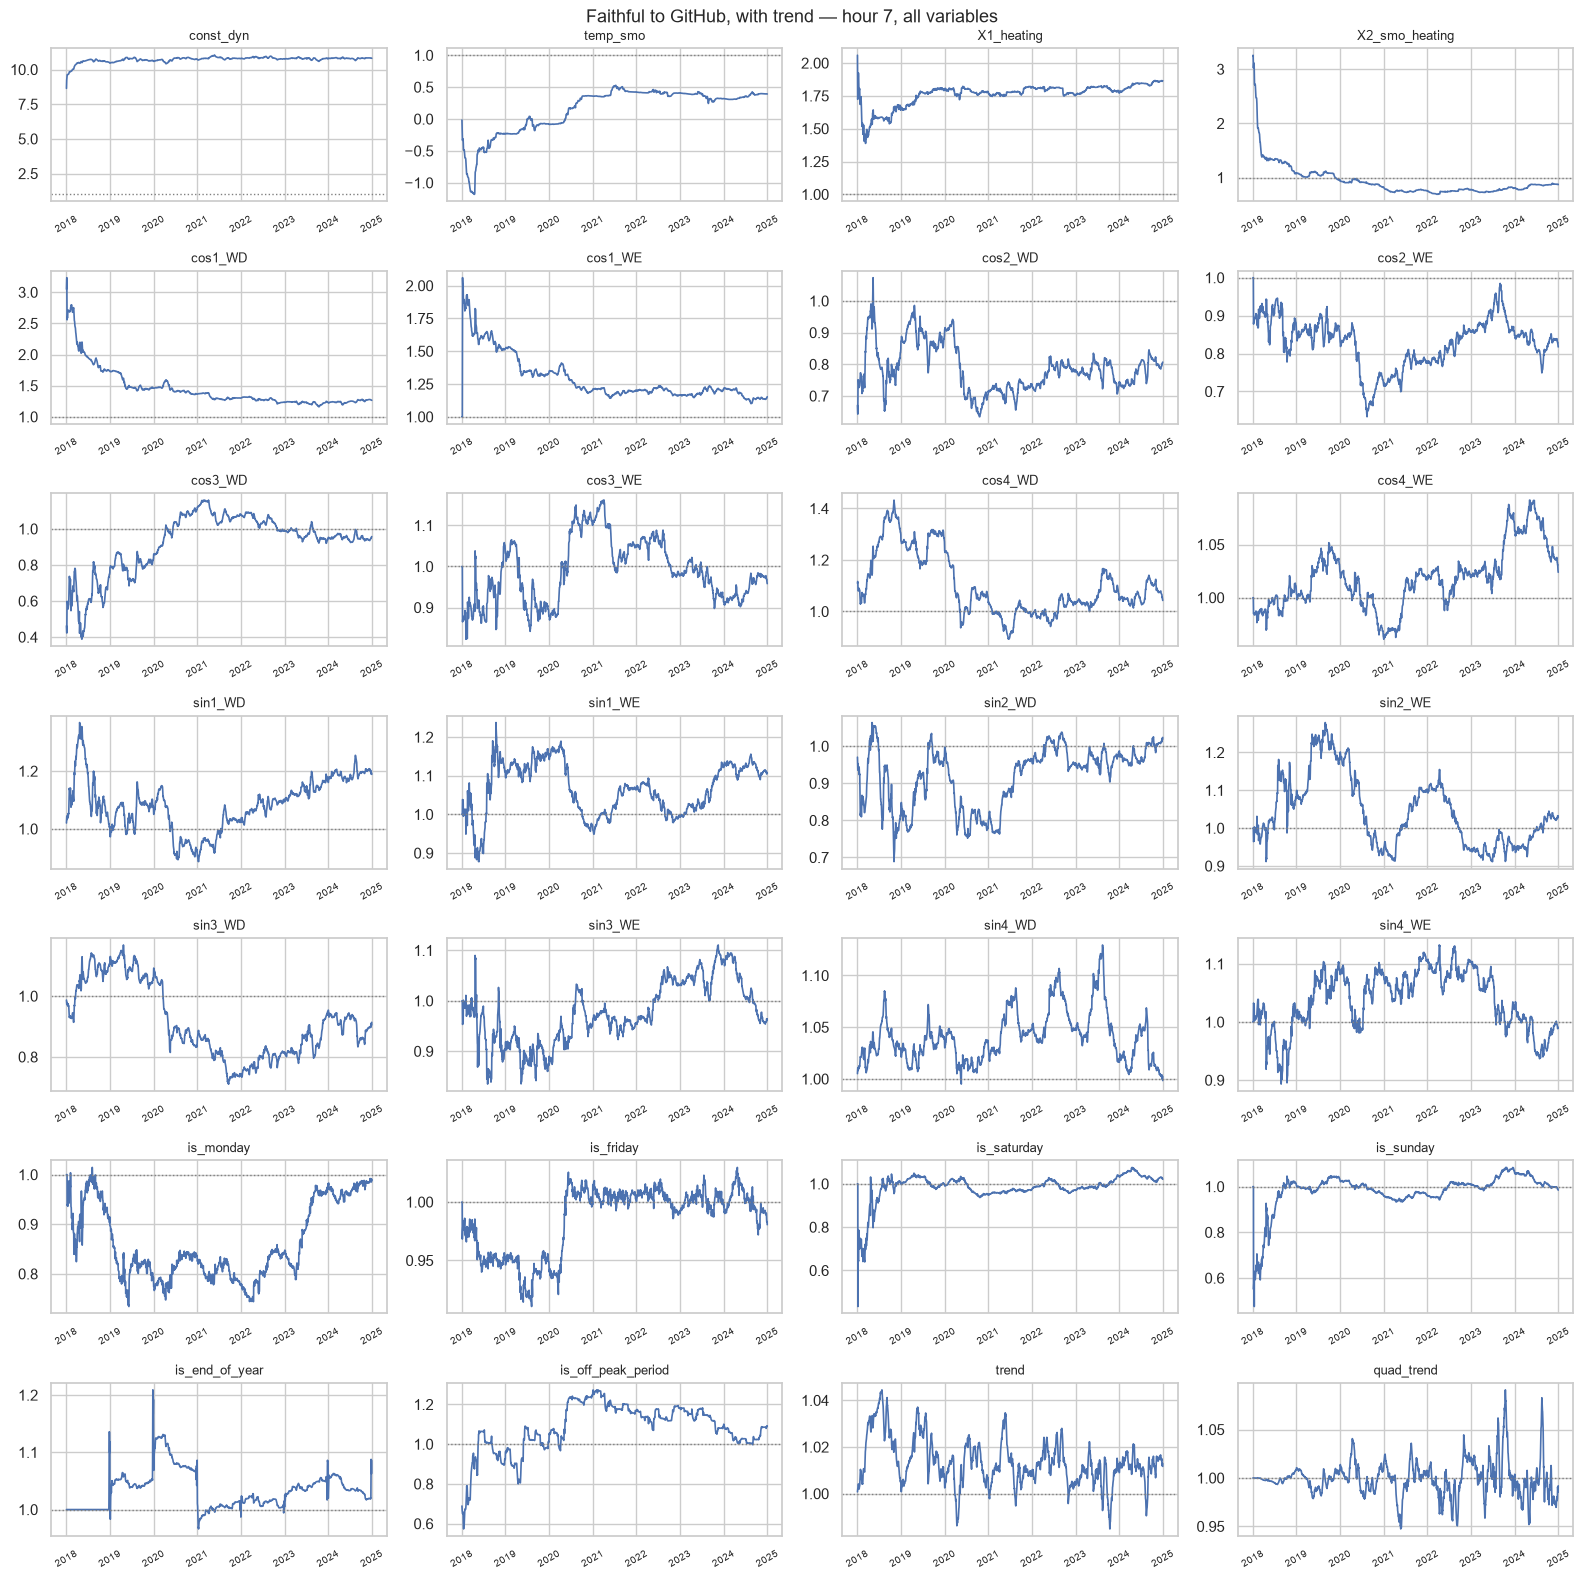

In [8]:
plot_all_trajectories(traj_faithful_with_trend, "Faithful to GitHub, with trend — hour 7, all variables")

## 2. The gain does converge — measured by day-to-day volatility
If the filter "did not converge" in the sense of an unstable gain, day-to-day variations would stay large until the end of training. That is not the case in any of the 3 variants: they all drop by an order of magnitude between the start and the end of the train period.

In [9]:
def volatility_table(traj, col):
    d = traj[col].diff()
    return {"std first 100 days": d.iloc[:100].std(), "std last 100 days": d.iloc[-100:].std(),
            "plage totale (min-max)": traj[col].max() - traj[col].min()}

pd.DataFrame({
    "Production": volatility_table(traj_production, "temp_smo"),
    "Faithful, no trend": volatility_table(traj_faithful_no_trend, "temp_smo"),
    "Faithful, with trend": volatility_table(traj_faithful_with_trend, "temp_smo"),
}).T.round(4)

,std first 100 days,std last 100 days,plage totale (min-max)
Production,0.0316,0.0038,1.7558
"Faithful, no trend",0.0212,0.0010,1.7810
"Faithful, with trend",0.0197,0.0010,1.7090


## Conclusion

**The filter itself has no bug**: in all 3 variants, the Kalman gain stabilizes correctly — day-to-day volatility drops by a factor of ~10 to ~30 between the start and the end of training (table above). An unstable gain would produce the opposite.

**What actually changes relative to the GitHub reference, and why the trajectory still looks visually "unconverged" on our data:**

1. **Dynamic vs fixed intercept.** Slipping the intercept into the state (as the reference notebook does) redistributes where the long-term drift is absorbed, but does not remove it — `const_dyn` must learn the whole log-target level starting from 1 (it ends around 10.5-10.8, consistent with `log(consumption)`), a different design from our production choice (fixed intercept = the SUR's β_0, per the provided slide).
2. **Fixed V=0.1 vs per-hour estimated V (~0.02).** A larger V makes the filter less reactive to each individual observation → smoother trajectory but not necessarily "truer".
3. **`trend`/`quad_trend` modestly reduces the amplitude but does not eliminate it.** Even with these variables (which do not exist in the Table 1 given as the specification), the range covered by the scale factor on `temp_smo` stays wide.
4. **The root cause is in the data, not the algorithm**: French gas consumption drops by about 30% between 2019 and 2025 (cell 2 above), largely due to the 2022 European energy crisis — a brutal shock that no Table 1 variable (nor even a smooth linear/quadratic trend) can represent faithfully. The Kalman filter does what it is asked to do: it absorbs this unmodeled drift by moving its adjustment factors, slowly but surely, over the whole training period.

In other words: convergence to a perfectly stable plateau would only be possible if the structural SUR already explained most of the long-term dynamics — which neither Table 1 nor its `trend` extension fully allows over this period, which includes a major structural shock.